In [63]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.neighbors import KDTree
from sklearn.neighbors import NearestNeighbors

import sys


from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs(camera="ximea")

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions(camera="ximea")

from pyS3M import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions(camera="ximea")

from pyS3M import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions(camera="ximea")

from pyS3M import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from pyS3M import render
from pyS3M import FiducialDetection

FD = FiducialDetection.FiducialDetector()


import types

import pyS3M.DriftCorrectionFunctions as DCF
from pyS3M.LinkingFunctions import link_localisations


smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [64]:
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [65]:
image_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260910_DNA_Nanorulers/80R_NanoRuler/60mW_638_1_DC1_LP635_75ms_TIRF_1"

In [66]:
localisation_files = H_F.file_search(image_folder, ".h5", "")

In [67]:
localisation_files

['/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260910_DNA_Nanorulers/80R_NanoRuler/60mW_638_1_DC1_LP635_75ms_TIRF_1/brendan_old/60mW_638_1_DC1_LP635_75ms_TIRF_1_MMStack_Default.h5',
 '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260910_DNA_Nanorulers/80R_NanoRuler/60mW_638_1_DC1_LP635_75ms_TIRF_1/brendan_old/60mW_638_1_DC1_LP635_75ms_TIRF_1_MMStack_Default_1.h5',
 '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260910_DNA_Nanorulers/80R_NanoRuler/60mW_638_1_DC1_LP635_75ms_TIRF_1/brendan_old/60mW_638_1_DC1_LP635_75ms_TIRF_1_MMStack_Default_2.h5',
 '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260910_DNA_Nanorulers/80R_NanoRuler/60mW_638_1_DC1_LP635_75ms_TIRF_1/brendan_old/60mW_638_1_DC1_LP635_75ms_TIRF_1_MMStack_Default_3.h5',
 '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260910_DNA_Nanorulers/80R_NanoRuler/60mW_638_1_DC1_LP635_75ms_TIRF_1/brendan_old/60mW_638_1_DC1_LP635_75ms_TIRF_1_MMSta

In [68]:
tif_files = H_F.file_search(image_folder, ".tif", "")

In [69]:
metadata_files = H_F.file_search(image_folder, "metadata", "")

In [70]:
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [71]:
loc_data = pd.read_hdf(localisation_files[0])

In [ ]:
loc_data = loc_data[loc_data["xc_err"] < 40/72]
loc_data = loc_data[loc_data["yc_err"] < 40/72]

loc_data = loc_data[loc_data["xc_err"] > 0]
loc_data = loc_data[loc_data["yc_err"] > 0]

loc_data = loc_data[loc_data["s_x_err"] < 40/72]
loc_data = loc_data[loc_data["s_y_err"] < 40/72]

loc_data = loc_data[(loc_data["s_x"] > 100/72) & (loc_data["s_x"] < 200/72)]
loc_data = loc_data[(loc_data["s_y"] > 100/72) & (loc_data["s_y"] < 200/72)]

loc_data = loc_data[loc_data["A_B_err"] < 0.01]
loc_data = loc_data[loc_data["A_G_err"] < 0.01]
loc_data = loc_data[loc_data["A_R_err"] < 0.01]

loc_data = loc_data[loc_data["A_B"] > 0.005]
loc_data = loc_data[loc_data["A_G"] > 0.05]
loc_data = loc_data[loc_data["A_R"] > 0.5]

loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
loc_data = loc_data[loc_data["bg_R_err"] < 0.15]

loc_data = loc_data[~((loc_data['photons'] < 500) & (loc_data['spot_matched_filter_response'] < 25))]

loc_data = loc_data[loc_data["spot_background_std"] > 4]

#loc_data = loc_data[loc_data["photons"] < 100000]
#loc_data = loc_data[loc_data["photons"] > 100]


loc_data = loc_data[loc_data["chi_sqr"] < 3]

In [ ]:
plt.hist(loc_data['A_R'], 1000, alpha=0.5, color='darkred');
plt.hist(loc_data['A_G'], 1000, alpha=0.5, color='darkgreen');
#plt.hist(loc_data['A_B'], 1000, alpha=0.5, color='lightblue');
plt.xlim([0, 1])
plt.show()

In [ ]:
image = render.render(
    locs=loc_data.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

In [ ]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs, image, colorbar=False)
plt.show()

In [ ]:
drift_corrector = DCF.Drift_Correction_Functions()

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

corrected_locs, drift_result = drift_corrector.undrift(locs=loc_data.to_records(index=False),
                                          info=info,
                                          method="aim",
                                          segmentation=20,
                                            intersect_d=20/72,
                                          roi_r=60/72,
                                         )
corrected_locs = pd.DataFrame(corrected_locs)

In [ ]:
plt.plot(drift_result.drift_x*72)
plt.plot(drift_result.drift_y*72)

plt.show()

In [ ]:
link_r = 0.5 * (np.median(corrected_locs['xc_err']) + np.median(corrected_locs['yc_err']))
linked = link_localisations(corrected_locs, n_frames=n_frames, r_max=link_r, max_dark_time=2)

In [72]:
linked = pd.read_hdf(localisation_files[-1])

## Whole-acquisition per-site consolidation (no assumed geometry)

**Precision shown on each consolidated point:** the median of that site's own assigned
localisations' individual `xc_err`/`yc_err` -- not a standard error of the mean (which would
shrink arbitrarily as more blinks are pooled in and imply more precision than any single
measurement actually has).

In [73]:
# --- Step 1: find candidate ruler regions in the drift-corrected, linked data ---
RULER_SITE_SPACING_NM = 80.0
pixel_size_nm = 69.0
site_spacing_px = RULER_SITE_SPACING_NM / pixel_size_nm

xc_link = linked['xc'].to_numpy()
yc_link = linked['yc'].to_numpy()
xc_err_link = linked['xc_err'].to_numpy()
yc_err_link = linked['yc_err'].to_numpy()

bin_sz_px = 2.0   # ~138nm bins -- coarse enough that no single bin spans two separate rulers
min_sep_bins = 6  # ~414nm minimum separation between distinct ruler regions
min_count = 200   # minimum localisations before a region is worth attempting a fit on

bins_x = np.arange(np.floor(xc_link.min()), np.ceil(xc_link.max()) + bin_sz_px, bin_sz_px)
bins_y = np.arange(np.floor(yc_link.min()), np.ceil(yc_link.max()) + bin_sz_px, bin_sz_px)
H, xe, ye = np.histogram2d(xc_link, yc_link, bins=(bins_x, bins_y))

flat_idx = np.argsort(H.ravel())[::-1]
picked = []
for idx in flat_idx:
    i, j = np.unravel_index(idx, H.shape)
    if H[i, j] < min_count:
        break
    if all(abs(i - pi) + abs(j - pj) > min_sep_bins for pi, pj in picked):
        picked.append((i, j))

region_centres = [((xe[i] + xe[i+1]) / 2, (ye[j] + ye[j+1]) / 2) for (i, j) in picked]
print(f"{len(region_centres)} candidate ruler regions detected")

936 candidate ruler regions detected


In [74]:
# --- Step 2: soft (EM-style) 3-component fit, per region -- geometry NOT assumed ---
CAPTURE_RADIUS_PX = 3.0  # ~207nm -- generous whole-ruler capture around each detected region
DEGENERATE_FRACTION = 0.05  # drop a resolution if any component ends up with < 5% of its points
N_INIT = 5
N_ITER = 30

# Known, fixed wobble covariance (lab frame) -- established this session: the real per-molecule
# positional wobble is elongated ~32nm (major) x ~19nm (minor) at a fixed ~135deg, independent
# of each ruler's own orientation. This is a noise/motion property, not the structure being
# measured, so using it as a fixed, shared component covariance isn't circular the way fixing
# the 80nm spacing would be -- see markdown above.
WOBBLE_MAJOR_SIGMA_NM = 32.0
WOBBLE_MINOR_SIGMA_NM = 19.0
WOBBLE_AXIS_DEG = 135.0

major_sig_px = WOBBLE_MAJOR_SIGMA_NM / pixel_size_nm
minor_sig_px = WOBBLE_MINOR_SIGMA_NM / pixel_size_nm
_theta_w = np.radians(WOBBLE_AXIS_DEG)
_Rw = np.array([[np.cos(_theta_w), -np.sin(_theta_w)], [np.sin(_theta_w), np.cos(_theta_w)]])
_WOBBLE_COV = _Rw @ np.diag([major_sig_px**2, minor_sig_px**2]) @ _Rw.T
_WOBBLE_COV_INV = np.linalg.inv(_WOBBLE_COV)
_WOBBLE_NORM = 1.0 / (2 * np.pi * np.sqrt(np.linalg.det(_WOBBLE_COV)))
_rng = np.random.default_rng(0)


def fit_ruler_free_gmm(pts_px, n_iter=N_ITER, n_init=N_INIT):
    '''Fit 3 independent Gaussian components (fixed, known wobble covariance; free means, no
    spacing or collinearity assumed) via EM, keeping the best of several initialisations by
    log-likelihood -- guards against a single bad random start collapsing a component.

    Returns (means_px (3,2), hard_assignment) or (None, None) if every init degenerated.
    '''
    best = None
    for init in range(n_init):
        if init == 0:
            pts_c = pts_px - pts_px.mean(axis=0)
            cov0 = pts_c.T @ pts_c / len(pts_c)
            evals, evecs = np.linalg.eigh(cov0)
            axis_vec = evecs[:, np.argmax(evals)]
            spread = np.sqrt(evals.max())
            means = pts_px.mean(axis=0) + np.array([-1, 0, 1])[:, None] * spread * axis_vec[None, :]
        else:
            idx = _rng.choice(len(pts_px), 3, replace=False)
            means = pts_px[idx].copy().astype(float)

        converged = True
        for _ in range(n_iter):
            diffs = pts_px[:, None, :] - means[None, :, :]
            maha = np.einsum('nkd,de,nke->nk', diffs, _WOBBLE_COV_INV, diffs)
            resp = _WOBBLE_NORM * np.exp(-0.5 * maha)
            resp /= (resp.sum(axis=1, keepdims=True) + 1e-300)
            weights = resp.sum(axis=0)
            if np.any(weights < 1e-6):
                converged = False
                break
            means = (resp[:, :, None] * pts_px[:, None, :]).sum(axis=0) / weights[:, None]
        if not converged:
            continue

        diffs = pts_px[:, None, :] - means[None, :, :]
        maha = np.einsum('nkd,de,nke->nk', diffs, _WOBBLE_COV_INV, diffs)
        resp = _WOBBLE_NORM * np.exp(-0.5 * maha)
        resp /= (resp.sum(axis=1, keepdims=True) + 1e-300)
        ll = np.log(resp.sum(axis=1) + 1e-300).sum()
        if best is None or ll > best[0]:
            best = (ll, means.copy(), resp.copy())

    if best is None:
        return None, None
    _, means, resp = best
    return means, np.argmax(resp, axis=1)


ruler_rows = []
n_resolved = 0
n_dropped = 0
for ridx, (cx, cy) in enumerate(region_centres):
    d2 = (xc_link - cx) ** 2 + (yc_link - cy) ** 2
    mask = d2 < CAPTURE_RADIUS_PX ** 2
    if mask.sum() < 200:
        continue
    pts_px = np.column_stack([xc_link[mask], yc_link[mask]])
    means, assign = fit_ruler_free_gmm(pts_px)
    if means is None:
        n_dropped += 1
        continue
    n_per_site = np.array([(assign == s).sum() for s in range(3)])
    if n_per_site.min() < DEGENERATE_FRACTION * n_per_site.sum():
        n_dropped += 1
        continue

    n_resolved += 1
    # order the 3 (not-necessarily-collinear) sites along their own dominant spread direction,
    # purely for readable site numbering -- not a fit constraint
    mean_c = means - means.mean(axis=0)
    _, _, Vt = np.linalg.svd(mean_c)
    order = np.argsort(mean_c @ Vt[0])
    for rank, s in enumerate(order):
        m = assign == s
        ruler_rows.append({
            "ruler_id": ridx, "site": rank,
            "xc": means[s, 0], "yc": means[s, 1],
            # honest precision: median of this site's own assigned single-fit errors, not a
            # standard-error-of-the-mean that would shrink the more blinks are pooled in
            "xc_err": np.median(xc_err_link[mask][m]),
            "yc_err": np.median(yc_err_link[mask][m]),
            "n_locs": int(m.sum()),
            "frame": 0,
        })

consolidated = pd.DataFrame(ruler_rows)
print(f"resolved {n_resolved}/{len(region_centres)} regions ({n_dropped} dropped as unreliable) "
      f"-> {len(consolidated)} consolidated sites")
if len(consolidated):
    print(f"median displayed precision: "
          f"{consolidated['xc_err'].median()*pixel_size_nm:.1f} nm (x), "
          f"{consolidated['yc_err'].median()*pixel_size_nm:.1f} nm (y)  "
          f"-- typical single-detection precision, not assumed")
consolidated.head(9)

resolved 933/936 regions (3 dropped as unreliable) -> 2799 consolidated sites
median displayed precision: 6.8 nm (x), 7.1 nm (y)  -- typical single-detection precision, not assumed


,ruler_id,site,xc,yc,xc_err,yc_err,n_locs,frame
0,0,0,491.659928,433.712660,0.124162,0.132372,9449,0
1,0,1,491.872289,435.460873,0.136474,0.144556,5829,0
2,0,2,490.362634,435.164053,0.134175,0.145131,10452,0
3,1,0,413.070923,313.078106,0.117618,0.113732,5891,0
4,1,1,411.942680,312.545400,0.091339,0.092513,6454,0
5,1,2,412.882951,311.303840,0.106055,0.106981,6873,0
6,2,0,137.587024,461.494473,0.120987,0.124833,5479,0
7,2,1,136.276540,461.179781,0.178266,0.173323,1943,0
8,2,2,136.133543,462.608586,0.120600,0.124179,5467,0


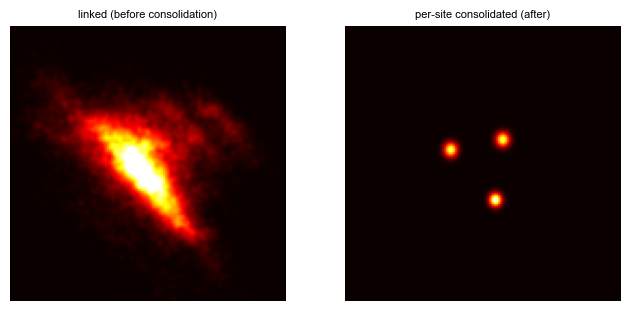

In [75]:
# --- Step 3: before/after comparison, zoomed on the best-populated resolved ruler ---
demo_ruler_id = consolidated.loc[consolidated.groupby("ruler_id")["n_locs"].transform("sum").idxmax(), "ruler_id"]
demo = consolidated[consolidated["ruler_id"] == demo_ruler_id]
cx_demo, cy_demo = demo[["xc", "yc"]].mean().to_numpy()

half_width_px = 4.0  # ~276nm half-width -- generous crop around one ruler
viewport = ((cy_demo - half_width_px, cx_demo - half_width_px),
            (cy_demo + half_width_px, cx_demo + half_width_px))
oversampling_demo = 16

info_demo = [{"Width": width, "Height": height, "Frames": 1, "Pixelsize": pixel_size_nm}]

image_before = render.render(
    locs=linked.to_records(index=False), info=info_demo,
    viewport=viewport, blur_method="smooth", oversampling=oversampling_demo,
)[1]

consolidated_render = consolidated.copy()
consolidated_render["xc_err"] = consolidated_render["xc_err"].clip(lower=0.01)
consolidated_render["yc_err"] = consolidated_render["yc_err"].clip(lower=0.01)
image_after = render.render(
    locs=consolidated_render.to_records(index=False), info=info_demo,
    viewport=viewport, blur_method="gaussian", oversampling=oversampling_demo,
)[1]

fig, axs = plotter.two_column_plot(ncols=2)
# image_plot auto-scales vmax from the 99th percentile, which works for the dense
# "before" image but breaks for the sparse "after" one (>99% background -> vmax~0,
# saturating the whole panel black) -- give it the real max explicitly instead.
axs[0], _ = plotter.image_plot(axs[0], image_before, cmap="hot", colorbar=False)
axs[0].set_title("linked (before consolidation)", fontsize=8)
axs[1], _ = plotter.image_plot(axs[1], image_after, cmap="hot", colorbar=False,
                                vmin=0, vmax=image_after.max())
axs[1].set_title("per-site consolidated (after)", fontsize=8)
plt.show()

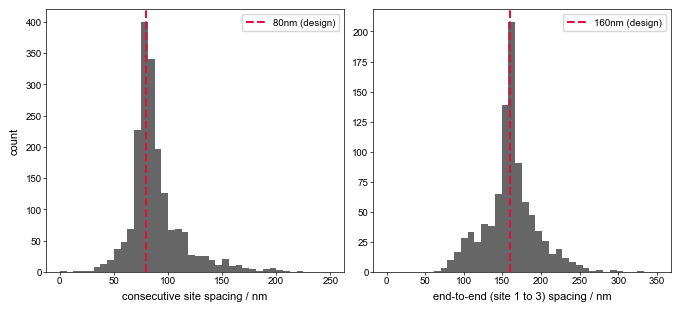

consecutive spacing: median=82.7nm  (n=1866)
end-to-end spacing:  median=159.5nm  (n=933)


In [76]:
# --- Step 4: population-level spacing validation -- the actual measurement, not an assumption ---
nn_spacings_nm = []
end_to_end_nm = []
for ridx, grp in consolidated.groupby("ruler_id"):
    grp = grp.sort_values("site")
    pts = grp[["xc", "yc"]].to_numpy() * pixel_size_nm
    nn_spacings_nm.append(np.linalg.norm(pts[1] - pts[0]))
    nn_spacings_nm.append(np.linalg.norm(pts[2] - pts[1]))
    end_to_end_nm.append(np.linalg.norm(pts[2] - pts[0]))

nn_spacings_nm = np.array(nn_spacings_nm)
end_to_end_nm = np.array(end_to_end_nm)

fig, axs = plotter.two_column_plot(ncols=2)
axs[0].hist(nn_spacings_nm, bins=40, range=(0, 250), color="0.4")
axs[0].axvline(80, color="crimson", ls="--", label="80nm (design)")
axs[0].set_xlabel("consecutive site spacing / nm", fontsize=8)
axs[0].set_ylabel("count", fontsize=8)
axs[0].legend(fontsize=7)

axs[1].hist(end_to_end_nm, bins=40, range=(0, 350), color="0.4")
axs[1].axvline(160, color="crimson", ls="--", label="160nm (design)")
axs[1].set_xlabel("end-to-end (site 1 to 3) spacing / nm", fontsize=8)
axs[1].legend(fontsize=7)
plt.show()

print(f"consecutive spacing: median={np.median(nn_spacings_nm):.1f}nm  (n={len(nn_spacings_nm)})")
print(f"end-to-end spacing:  median={np.median(end_to_end_nm):.1f}nm  (n={len(end_to_end_nm)})")

**Note:** `linked` and the rendering/fiducial-removal pipeline below are unchanged and still
run on the original per-localisation data -- this section adds `consolidated` as a new,
independent output (one row per resolved site, `ruler_id`/`site`/`n_locs` plus the usual
`xc`/`yc`/`xc_err`/`yc_err`) rather than replacing what the rest of the notebook consumes.
Swap the cells below to render/measure from `consolidated` once you're happy with it.

In [78]:
oversampling = 16

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(consolidated['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image = render.render(
            locs=consolidated.to_records(index=False),
            info=info,
            blur_method="gaussian",
            oversampling=oversampling
        )[1]  # Take the rendered image

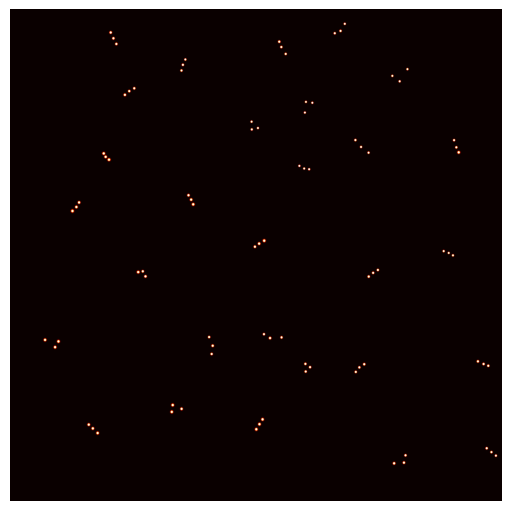

In [82]:
fig, axs = plotter.two_column_plot(height=5, width=5)

axs = plotter.image_plot(axs, image[:oversampling*100, :oversampling*100], cmap='hot', colorbar=False,
                        vmin=np.percentile(image, 0.1), vmax=np.percentile(image, 99.9))

plt.show()

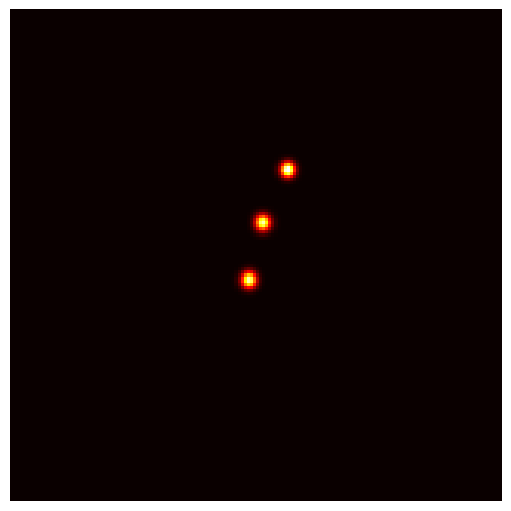

In [94]:
fig, axs = plotter.two_column_plot(height=5, width=5)

axs = plotter.image_plot(axs, image[oversampling*83:oversampling*93, oversampling*30:oversampling*40], cmap='hot', colorbar=False,
                        vmin=np.percentile(image, 0.1), vmax=np.percentile(image, 99.99))

plt.show()